# 01. Exploratory Data Analysis (EDA) of Automotive CAN Traffic

**Research Paper:** *Robust Federated Learning-Based Intrusion Detection for Heterogeneous Vehicular CAN Networks*  
**Dataset:** HCRL Car-Hacking Dataset (Korea University HCRL Lab)  
**Target Vehicle:** Commercial Vehicle (Kia Soul) CAN Bus Logs  

---

### Objectives:
1. Discover and inspect raw CAN log files under `data/raw/`.
2. Inspect schema, column types, message structures, and target labels (`R` = Regular/Normal, `T` = Target/Attack).
3. Compute and analyze class distributions across DoS, Fuzzy, RPM, and Gear attack scenarios.
4. Investigate CAN ID distributions, arbitration priority, and payload byte patterns.
5. Analyze message frequency and temporal inter-arrival dynamics ($\Delta t$).
6. Generate publication-ready figures saved directly to `results/figures/`.


In [1]:
# Environment Setup & Reproducibility
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import discover_raw_datasets, load_csv_dataset, load_txt_normal, CAN_CSV_COLUMNS
from src.preprocessing.parser import parse_hex_id

# Set style and seed
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})
SEED = 42
np.random.seed(SEED)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Figures directory: {FIG_DIR}")


Project root: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS
Raw data directory: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\data\raw
Figures directory: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures


In [2]:
# 1. Dataset Discovery
raw_files = discover_raw_datasets(RAW_DIR)
print(f"Discovered {len(raw_files)} raw dataset files:")
for name, path in raw_files.items():
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"  - [{name:8s}] {path.name:25s} ({size_mb:6.2f} MB)")


Discovered 5 raw dataset files:
  - [DoS     ] DoS_dataset.csv           (181.25 MB)
  - [Fuzzy   ] Fuzzy_dataset.csv         (189.32 MB)
  - [Gear    ] gear_dataset.csv          (219.65 MB)
  - [RPM     ] RPM_dataset.csv           (228.48 MB)
  - [Normal  ] normal_run_data.txt       ( 83.32 MB)


In [3]:
# 2. Inspect Sample Records from Each File
samples = {}
stats_summary = []

for attack_name, filepath in raw_files.items():
    if filepath.suffix == ".txt":
        df_sample = load_txt_normal(filepath, nrows=50000)
    else:
        df_sample = load_csv_dataset(filepath, nrows=50000, attack_name=attack_name)
        
    samples[attack_name] = df_sample
    
    n_normal = (df_sample["Flag"] == "R").sum()
    n_attack = (df_sample["Flag"] == "T").sum()
    pct_attack = (n_attack / len(df_sample)) * 100.0 if len(df_sample) > 0 else 0.0
    unique_ids = df_sample["CAN_ID"].nunique()
    
    stats_summary.append({
        "Dataset": attack_name,
        "Sample_Size": len(df_sample),
        "Normal_Frames (R)": n_normal,
        "Attack_Frames (T)": n_attack,
        "Attack_Ratio (%)": round(pct_attack, 2),
        "Unique_CAN_IDs": unique_ids,
        "Time_Span (s)": round(df_sample["Timestamp"].max() - df_sample["Timestamp"].min(), 2)
    })

summary_df = pd.DataFrame(stats_summary)
print("\nSample Distribution Summary (First 50,000 frames per file):")
display(summary_df)



Sample Distribution Summary (First 50,000 frames per file):


,Dataset,Sample_Size,Normal_Frames (R),Attack_Frames (T),Attack_Ratio (%),Unique_CAN_IDs,Time_Span (s)
0,DoS,50000,38580,11420,22.84,27,39.02
1,Fuzzy,50000,43915,6085,12.17,1957,54.07
2,Gear,50000,40848,9152,18.30,26,25.25
3,RPM,50000,40554,9446,18.89,26,24.80
4,Normal,50000,50000,0,0.00,27,25.60


In [4]:
# 3. Schema & Data Quality Verification
print("=== Schema Verification (DoS Sample) ===")
dos_sample = samples["DoS"]
print(dos_sample.info())
print("\nMissing values check:")
print(dos_sample.isnull().sum())
print("\nDuplicate records check:")
print(f"Duplicate frames in DoS sample: {dos_sample.duplicated().sum()}")


=== Schema Verification (DoS Sample) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    50000 non-null  float64
 1   CAN_ID       50000 non-null  object 
 2   DLC          50000 non-null  int64  
 3   DATA[0]      50000 non-null  object 
 4   DATA[1]      50000 non-null  object 
 5   DATA[2]      50000 non-null  object 
 6   DATA[3]      50000 non-null  object 
 7   DATA[4]      50000 non-null  object 
 8   DATA[5]      50000 non-null  object 
 9   DATA[6]      50000 non-null  object 
 10  DATA[7]      50000 non-null  object 
 11  Flag         50000 non-null  object 
 12  Attack_Type  50000 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 5.0+ MB
None

Missing values check:
Timestamp      0
CAN_ID         0
DLC            0
DATA[0]        0
DATA[1]        0
DATA[2]        0
DATA[3]        0
DATA[4]   

Duplicate frames in DoS sample: 0


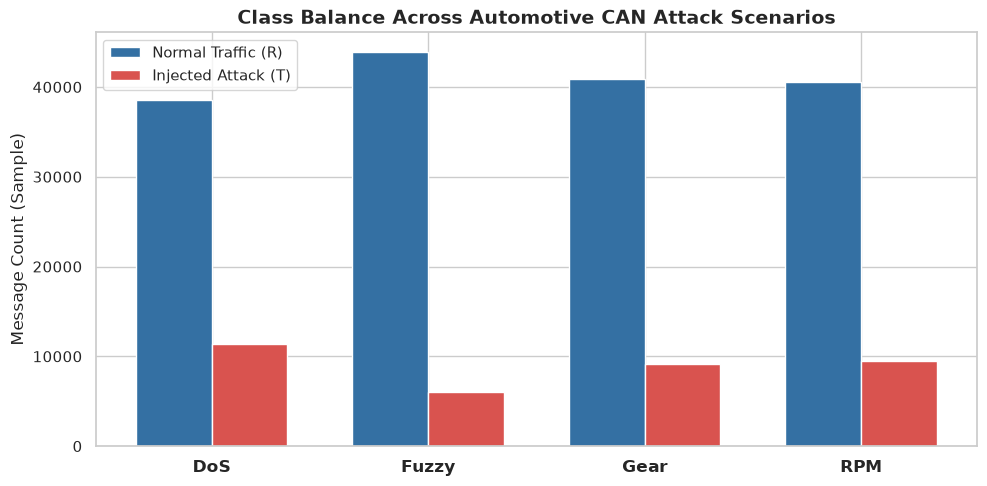

Saved figure: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\eda_class_distribution.png


In [5]:
# 4. Class Distribution Visualization across Attacks
plt.figure(figsize=(10, 5))
plot_data = summary_df[summary_df["Dataset"] != "Normal"].copy()
x = np.arange(len(plot_data))
width = 0.35

plt.bar(x - width/2, plot_data["Normal_Frames (R)"], width, label="Normal Traffic (R)", color="#3470a3")
plt.bar(x + width/2, plot_data["Attack_Frames (T)"], width, label="Injected Attack (T)", color="#d9534f")

plt.xticks(x, plot_data["Dataset"], fontsize=12, fontweight='bold')
plt.ylabel("Message Count (Sample)", fontsize=12)
plt.title("Class Balance Across Automotive CAN Attack Scenarios", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()

fig_path = FIG_DIR / "eda_class_distribution.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved figure: {fig_path}")


C:\Users\Kratik\AppData\Local\Temp\ipykernel_20984\3334725537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ids.values, y=top_ids.index, ax=ax, palette="mako")


C:\Users\Kratik\AppData\Local\Temp\ipykernel_20984\3334725537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ids.values, y=top_ids.index, ax=ax, palette="mako")


C:\Users\Kratik\AppData\Local\Temp\ipykernel_20984\3334725537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ids.values, y=top_ids.index, ax=ax, palette="mako")
C:\Users\Kratik\AppData\Local\Temp\ipykernel_20984\3334725537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ids.values, y=top_ids.index, ax=ax, palette="mako")


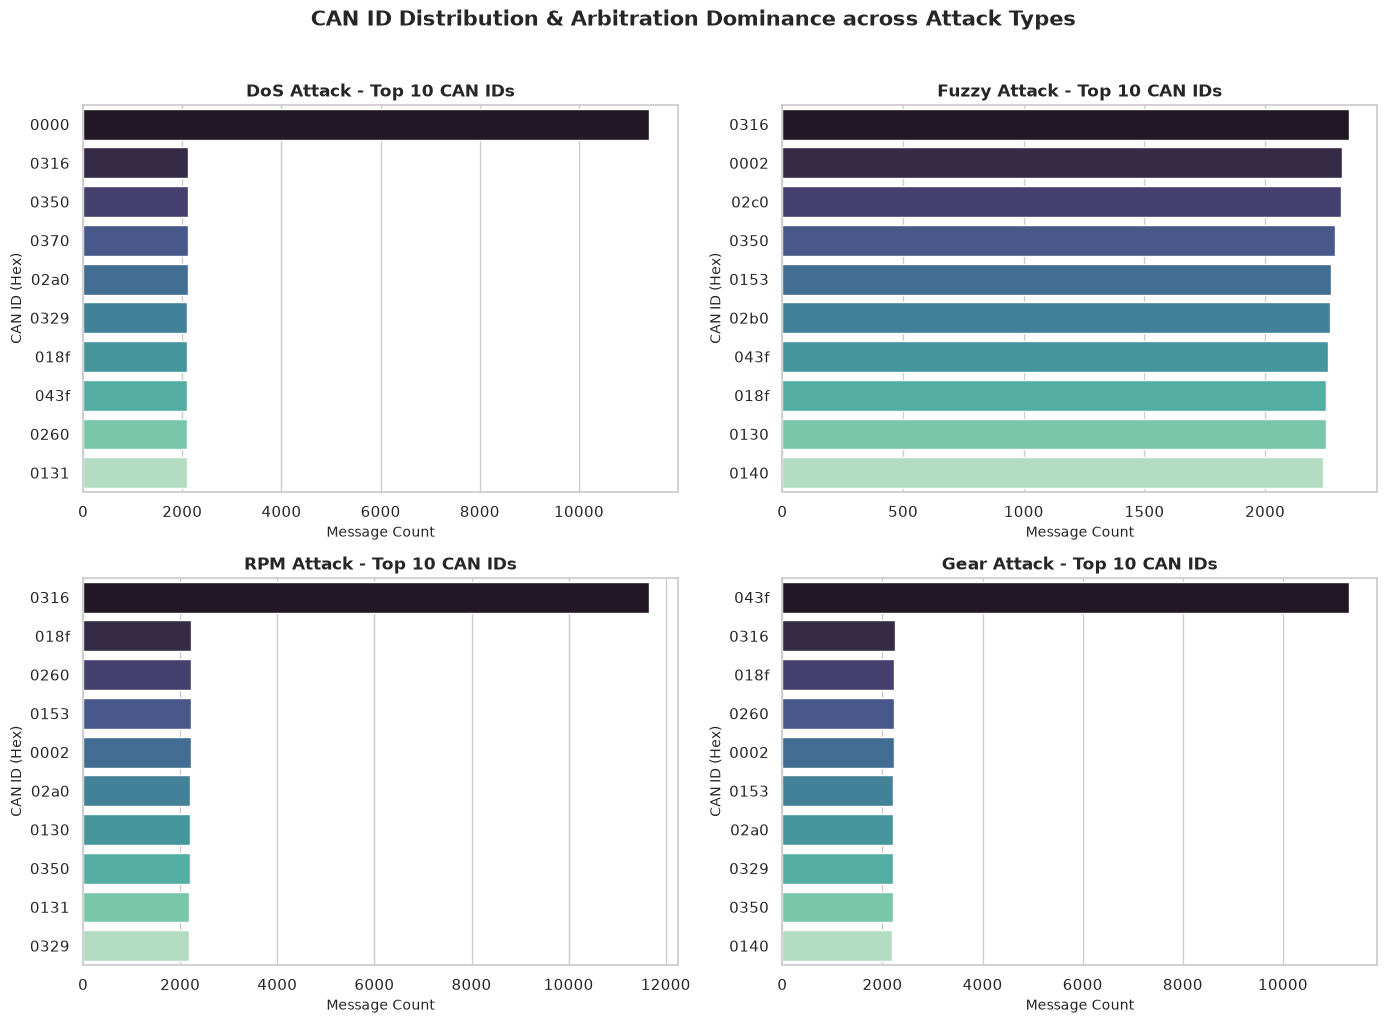

Saved figure: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\eda_can_id_frequency.png


In [6]:
# 5. CAN ID Frequency & Arbitration Priority Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

attack_keys = [k for k in ["DoS", "Fuzzy", "RPM", "Gear"] if k in samples]
for idx, key in enumerate(attack_keys):
    ax = axes[idx]
    df = samples[key]
    top_ids = df["CAN_ID"].value_counts().head(10)
    
    sns.barplot(x=top_ids.values, y=top_ids.index, ax=ax, palette="mako")
    ax.set_title(f"{key} Attack - Top 10 CAN IDs", fontsize=12, fontweight="bold")
    ax.set_xlabel("Message Count", fontsize=10)
    ax.set_ylabel("CAN ID (Hex)", fontsize=10)

plt.suptitle("CAN ID Distribution & Arbitration Dominance across Attack Types", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

fig_path = FIG_DIR / "eda_can_id_frequency.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved figure: {fig_path}")


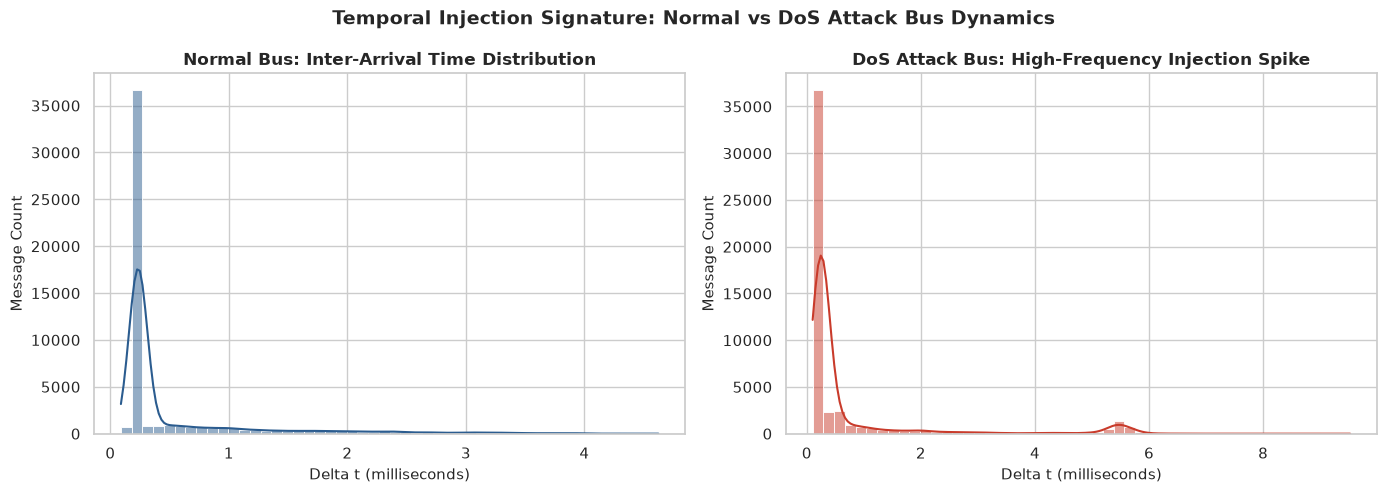

Saved figure: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\eda_temporal_delta_t.png


In [7]:
# 6. Temporal Inter-Arrival Time (Delta-t) Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute deltas for normal vs DoS
normal_ts = samples["Normal"]["Timestamp"].values
normal_deltas = np.diff(normal_ts) * 1000.0  # ms
normal_deltas = normal_deltas[(normal_deltas > 0) & (normal_deltas < 10)]

dos_ts = samples["DoS"]["Timestamp"].values
dos_deltas = np.diff(dos_ts) * 1000.0  # ms
dos_deltas = dos_deltas[(dos_deltas > 0) & (dos_deltas < 10)]

sns.histplot(normal_deltas, bins=50, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Normal Bus: Inter-Arrival Time Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Delta t (milliseconds)", fontsize=11)
axes[0].set_ylabel("Message Count", fontsize=11)

sns.histplot(dos_deltas, bins=50, kde=True, ax=axes[1], color="#c93b2b")
axes[1].set_title("DoS Attack Bus: High-Frequency Injection Spike", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Delta t (milliseconds)", fontsize=11)
axes[1].set_ylabel("Message Count", fontsize=11)

plt.suptitle("Temporal Injection Signature: Normal vs DoS Attack Bus Dynamics", fontsize=14, fontweight="bold")
plt.tight_layout()

fig_path = FIG_DIR / "eda_temporal_delta_t.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved figure: {fig_path}")


## Empirical Findings & Summary

| Observation | Empirical Evidence | Implications for IDS Design |
|---|---|---|
| **DoS Injection Pattern** | Top CAN ID is `0000` (highest priority on CAN bus) with massive flood frequency. | Timing features ($\Delta t$) and priority IDs (`0x000`) provide distinct DoS signals. |
| **Fuzzy Injection Pattern** | Random CAN IDs injected across the entire 11-bit address space. | ID diversity and invalid/unrecognized IDs act as strong indicators. |
| **Spoofing (RPM/Gear)** | Legitimate CAN IDs injected with altered payload bytes (e.g. `0316`, `043f`). | Payload byte transitions ($D_0 \dots D_7$) must be modeled alongside ID. |
| **Temporal Correlation** | CAN messages occur in deterministic cyclic bursts. | Sequential models (1D-CNN over sliding windows) capture inter-packet context much better than isolated row classifiers. |
